<a href="https://colab.research.google.com/github/ahmadsofian/GAN-for-Synthetic-Data-Generation/blob/main/Statistical_Similarity_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp

file_path1 = '/content/drive/MyDrive/IoT23/DDoS.csv'
file_path2 = '/content/drive/MyDrive/IoT23/DDoS_synthetic125.csv'


df_real = pd.read_csv(file_path1)
df_synthetic = pd.read_csv(file_path2)

print("real shape:", df_real.shape)

print("synthetic shape:", df_synthetic.shape)

real shape: (103992, 23)
synthetic shape: (46008, 23)


KS-TEST - Identical/Fidelity ---------------------------------------------------

In [ ]:
from scipy.stats import ks_2samp

def run_ks_test(real_data, synth_data):
    results = []

    # Identify numerical columns only (KS test is not for categorical strings)
    numeric_cols = real_data.select_dtypes(include=[np.number]).columns

    print(f"{'Column':<20} | {'KS Statistic'} | {'p-value'}| {'Result'}")
    print("-" * 70)

    for col in numeric_cols:
        if col not in synth_data.columns:
            continue

        # Run the KS Test
        stat, p_value = ks_2samp(real_data[col], synth_data[col])

        # Interpretation
        # Statistic: 0.0 means identical, 1.0 means completely different.
        #  < 0.1 for a "good" generation.
        if stat < 0.05:
            match_quality = "Excellent"
        elif stat < 0.1:
            match_quality = "Good"
        elif stat < 0.2:
            match_quality = "Fair"
        else:
            match_quality = "Poor"

        results.append({
            'Column': col,
            'KS_Statistic': stat,
            'P_Value': p_value,
            'Quality': match_quality
        })

        print(f"{col:<20} | {stat:.4f} | {p_value:.4f} | {match_quality}")

    return pd.DataFrame(results)

# Run the function
ks_results = run_ks_test(df_real, df_synthetic)

Column               | KS Statistic | p-value| Result
----------------------------------------------------------------------
duration             | 0.0189 | 0.0000 | Excellent
orig_bytes           | 0.0002 | 1.0000 | Excellent
resp_bytes           | 0.0000 | 1.0000 | Excellent
missed_bytes         | 0.0000 | 1.0000 | Excellent
orig_pkts            | 0.0064 | 0.1413 | Excellent
orig_ip_bytes        | 0.0064 | 0.1465 | Excellent
proto_icmp           | 0.0000 | 1.0000 | Excellent
proto_tcp            | 0.0002 | 1.0000 | Excellent
proto_udp            | 0.0002 | 1.0000 | Excellent
conn_state_OTH       | 0.0056 | 0.2622 | Excellent
conn_state_REJ       | 0.0001 | 1.0000 | Excellent
conn_state_RSTO      | 0.0000 | 1.0000 | Excellent
conn_state_RSTOS0    | 0.0000 | 1.0000 | Excellent
conn_state_RSTR      | 0.0000 | 1.0000 | Excellent
conn_state_RSTRH     | 0.0000 | 1.0000 | Excellent
conn_state_S0        | 0.0056 | 0.2751 | Excellent
conn_state_S3        | 0.0000 | 1.0000 | Excellent
conn_sta

Classifier Two-Sample Test (C2ST)

RFC Fidelity Test Accuracy: 0.7618162095149543

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.73      0.75     12906
           1       0.75      0.79      0.77     12906

    accuracy                           0.76     25812
   macro avg       0.76      0.76      0.76     25812
weighted avg       0.76      0.76      0.76     25812



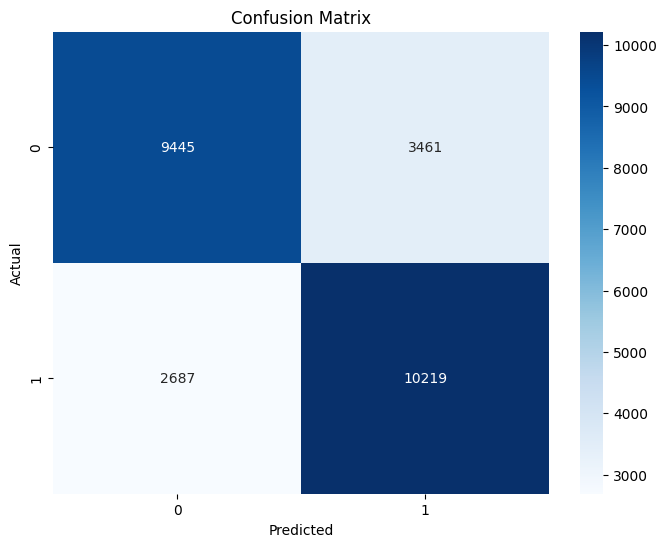

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# df_synthetic = df_synthetic.sample(n=len(df_real), random_state=42)  #--uncomment if the synthetic < real
df_real = df_real.sample(n=len(df_synthetic), random_state=42)

df_real['label'] = '1'
df_synthetic['label'] = '0'

combined = pd.concat([df_real, df_synthetic], axis=0).sample(frac=1).reset_index(drop=True)

X = combined.drop(['label'], axis=1)
y = combined['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("RFC Fidelity Test Accuracy:", acc)
print("\nClassification Report:\n", cr)



import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


Wasserstein Distance

Analyzing specific columns: ['duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'conn_rate_1s', 'unique_ports_1m', 'iat']

--- Detailed Scores ---
            Column        Raw_WD   Baseline_WD  Normalized_WD
0         duration      0.311324      0.200474       0.000052
1       orig_bytes  37070.413436  48072.088507       0.000021
2       resp_bytes      0.000000      0.000000       0.000000
3     missed_bytes      0.000000      0.000000       0.000000
4        orig_pkts   1956.660996   1138.104758       0.000030
5    orig_ip_bytes  91861.024494  48869.349412       0.000048
6     conn_rate_1s     49.129734      6.826717       0.005744
7  unique_ports_1m      0.121132      0.001942       0.020189
8              iat      0.030094      0.015047       0.000066


/tmp/ipython-input-1760267344.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Normalized_WD', y='Column', palette='viridis')


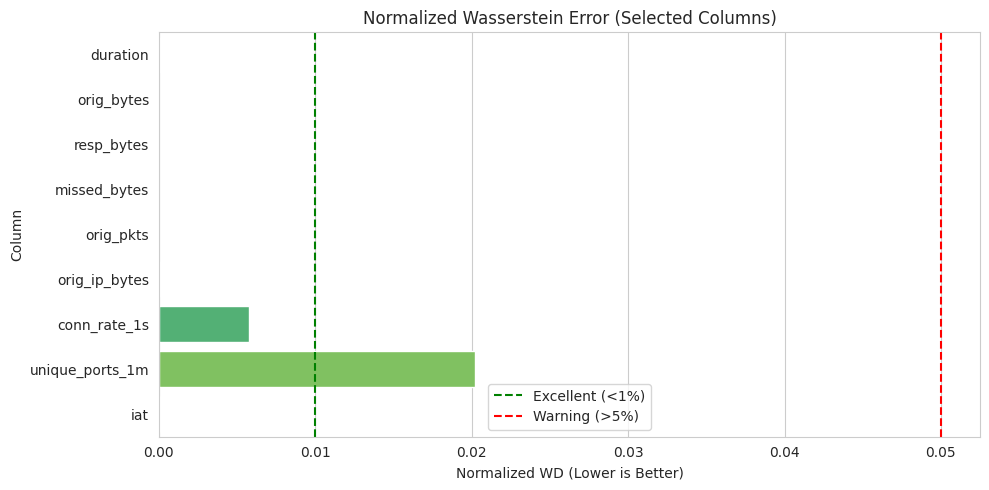

/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


KeyboardInterrupt: 

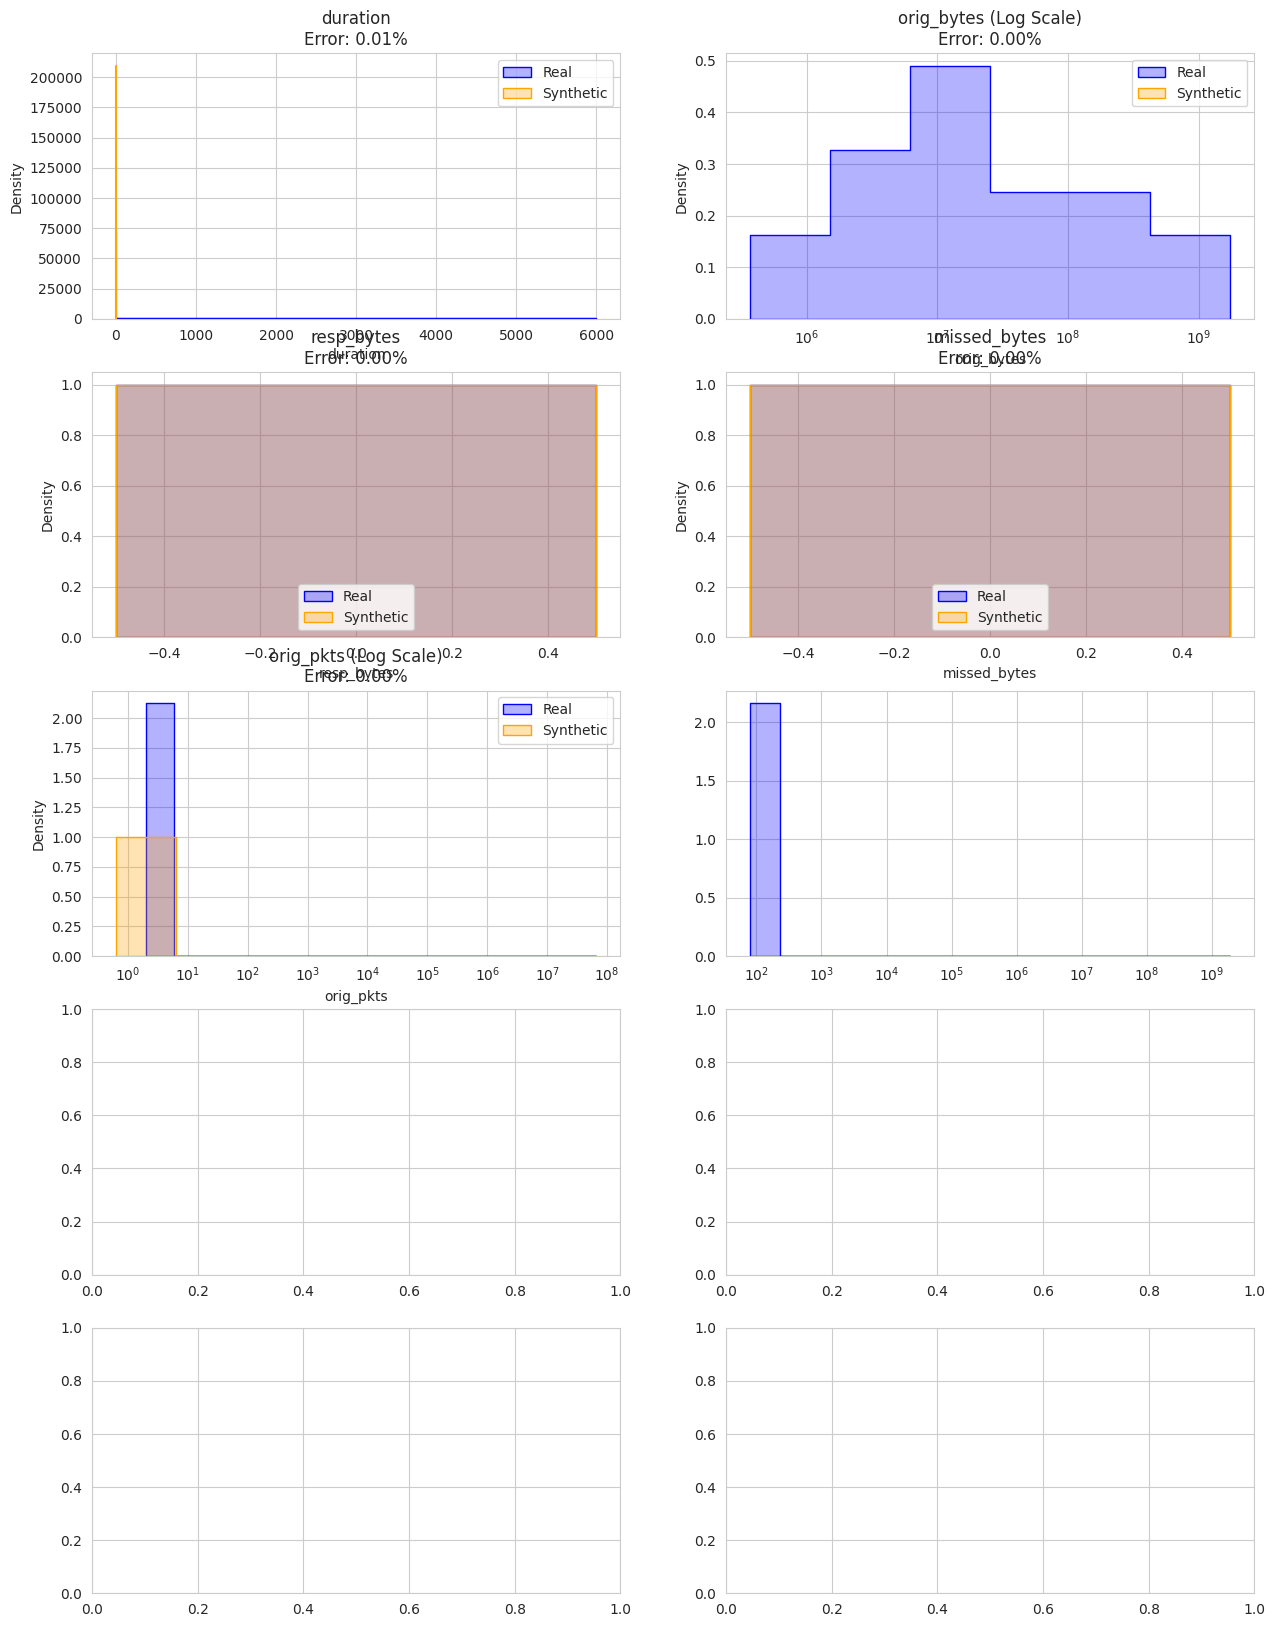

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance

# --- 0. Setup Selected Columns ---
selected_columns = ['duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts',
       'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes','conn_rate_1s', 'unique_ports_1m', 'iat']

# --- 1. Calculation Function ---
def evaluate_selected_wasserstein(df_real, df_syn, target_cols):
    results = []

    # Filter for columns that actually exist in the dataframe to avoid errors
    existing_cols = [c for c in target_cols if c in df_real.columns and c in df_syn.columns]

    if len(existing_cols) < len(target_cols):
        print(f"Warning: Missing columns in dataset. Analyzing only: {existing_cols}")

    for col in existing_cols:
        r_data = df_real[col].dropna().values
        s_data = df_syn[col].dropna().values

        if len(r_data) == 0 or len(s_data) == 0:
            continue

        # A. Raw Wasserstein
        wd = wasserstein_distance(r_data, s_data)

        # B. Baseline (Real vs Real split) for comparison
        np.random.shuffle(r_data)
        split = len(r_data) // 2
        baseline = wasserstein_distance(r_data[:split], r_data[split:]) if split > 0 else 0

        # C. Normalized (0-1 scale)
        col_range = np.max(r_data) - np.min(r_data)
        norm_wd = wd / col_range if col_range > 0 else 0.0

        results.append({
            'Column': col,
            'Raw_WD': wd,
            'Baseline_WD': baseline,
            'Normalized_WD': norm_wd
        })

    return pd.DataFrame(results)

# --- 2. Visualization Function ---
def plot_selected_columns(df_real, df_syn, df_results):
    sns.set_style("whitegrid")

    # Get the list of columns we actually analyzed
    plot_cols = df_results['Column'].tolist()
    n_cols = len(plot_cols)

    # --- Chart A: Summary Bar Chart ---
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_results, x='Normalized_WD', y='Column', palette='viridis')
    plt.title('Normalized Wasserstein Error (Selected Columns)')
    plt.xlabel('Normalized WD (Lower is Better)')
    plt.axvline(0.01, color='green', linestyle='--', label='Excellent (<1%)')
    plt.axvline(0.05, color='red', linestyle='--', label='Warning (>5%)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Chart B: Histograms (Dynamic Grid) ---
    # Calculate grid size (e.g., 2 columns wide)
    cols_wide = 2
    rows_tall = int(np.ceil(n_cols / cols_wide))

    fig, axes = plt.subplots(rows_tall, cols_wide, figsize=(15, 4 * rows_tall))
    axes = axes.flatten()

    for i, col in enumerate(plot_cols):
        ax = axes[i]

        # We use log scale for Bytes/Pkts often because they have long tails
        # Check if log scale makes sense (if max value is huge)
        use_log = False
        if df_real[col].max() > 10000: # Heuristic for large ranges like bytes
            use_log = True

        sns.histplot(df_real[col], ax=ax, color='blue', label='Real',
                     kde=True, stat="density", element="step", alpha=0.3, log_scale=use_log)

        sns.histplot(df_syn[col], ax=ax, color='orange', label='Synthetic',
                     kde=True, stat="density", element="step", alpha=0.3, log_scale=use_log)

        # Add score to title
        score = df_results[df_results['Column']==col]['Normalized_WD'].values[0]
        scale_label = " (Log Scale)" if use_log else ""
        ax.set_title(f"{col}{scale_label}\nError: {score:.2%}")
        ax.legend()

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# --- EXECUTION ---
print(f"Analyzing specific columns: {selected_columns}")
df_scores = evaluate_selected_wasserstein(df_real, df_synthetic, selected_columns)

print("\n--- Detailed Scores ---")
print(df_scores[['Column', 'Raw_WD', 'Baseline_WD', 'Normalized_WD']])

plot_selected_columns(df_real, df_synthetic, df_scores)

Correlation Matrix

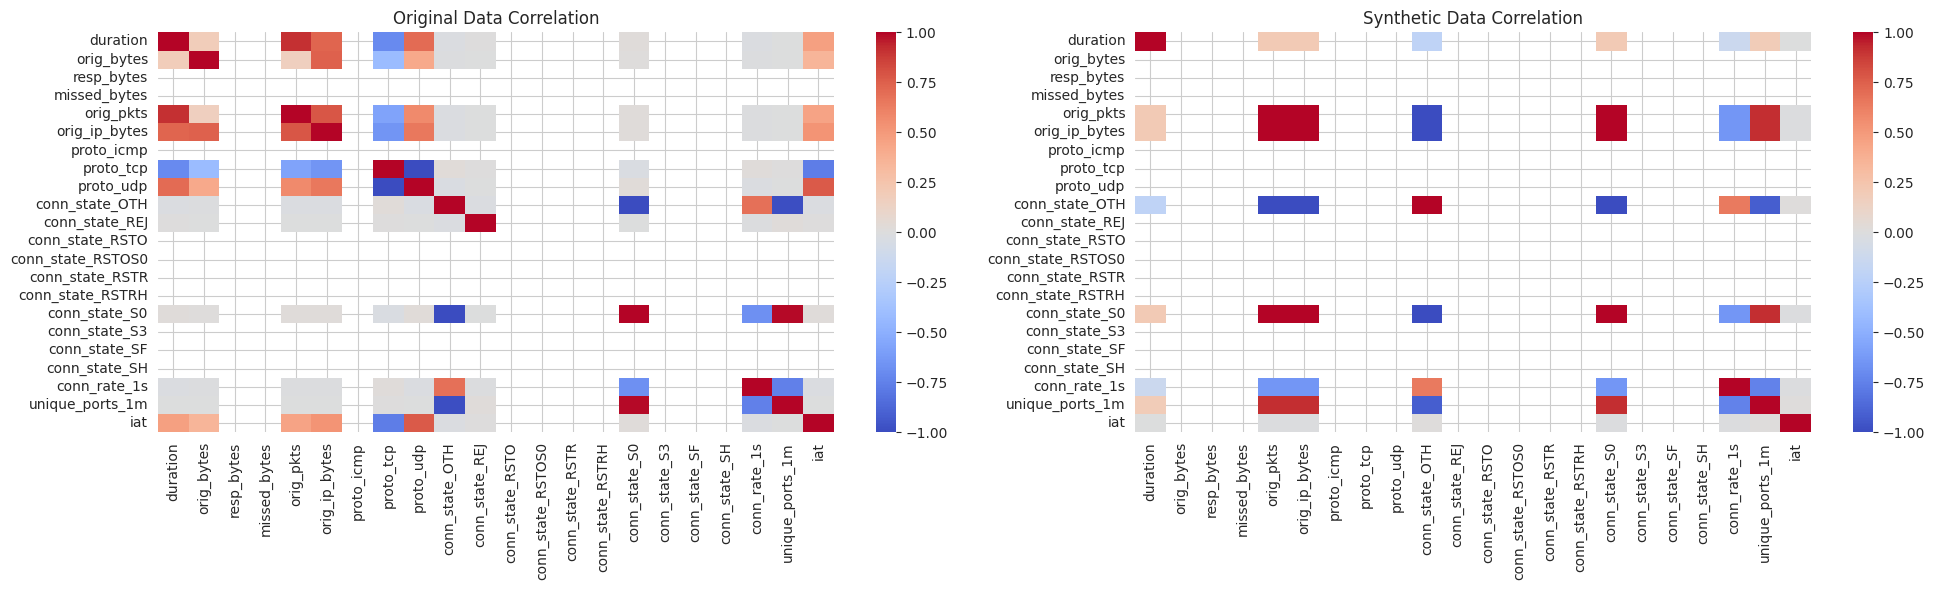

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Select numeric columns only (Correlation requires numeric data)
real_numeric = df_real.select_dtypes(include=[np.number])
synth_numeric = df_synthetic.select_dtypes(include=[np.number])

# Ensure both datasets have the same columns for comparison
common_cols = real_numeric.columns.intersection(synth_numeric.columns)
real_numeric = real_numeric[common_cols]
synth_numeric = synth_numeric[common_cols]

# 3. Compute Correlation Matrices
corr_real = real_numeric.corr()
corr_synth = synth_numeric.corr()

# 4. Visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Heatmap for Original Data
sns.heatmap(corr_real, annot=False, cmap='coolwarm', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Original Data Correlation')

# Heatmap for Synthetic Data
sns.heatmap(corr_synth, annot=False, cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Synthetic Data Correlation')

plt.tight_layout()
plt.show()

PCA/t-SNE --- Diversity

* Good Diversity: The synthetic (red) dots are spread out effectively covering the entire area of the real (blue) dots.

* Mode Collapse (Bad): The synthetic dots are clumped into one tight ball, while the real data is spread out. This means your GAN only learned one specific type of packet and ignored the rest.

Real Variance: 17865190874599.09
Synthetic Variance: 968240.05
>> RESULT: HIGH RISK of Mode Collapse (Synthetic variance is tiny!)


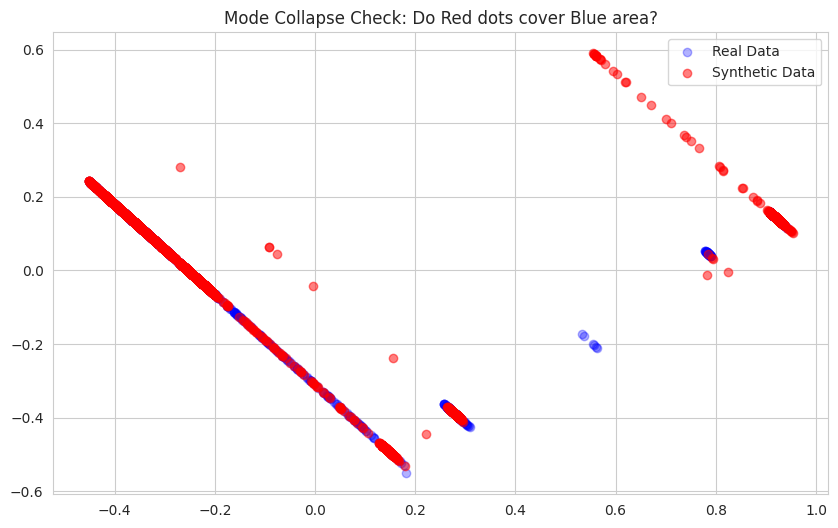

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# 2. Select Numerical Columns
cols = ['duration', 'orig_bytes', 'resp_bytes', 'orig_pkts',
       'orig_ip_bytes', 'conn_rate_1s', 'unique_ports_1m', 'iat']

r_data = df_real[cols].values
s_data = df_synthetic[cols].values

# --- TEST 1: VARIANCE CHECK ---
r_var = np.var(r_data, axis=0).mean()
s_var = np.var(s_data, axis=0).mean()

print(f"Real Variance: {r_var:.2f}")
print(f"Synthetic Variance: {s_var:.2f}")

if s_var < (r_var * 0.1):
    print(">> RESULT: HIGH RISK of Mode Collapse (Synthetic variance is tiny!)")
else:
    print(">> RESULT: Variance looks healthy.")

# --- TEST 2: PCA VISUALIZATION ---
# Sample down if datasets are huge (e.g., 2000 points)
n_samples = min(5000, len(df_real), len(df_synthetic))
r_subset = df_real.sample(n=n_samples)[cols]
s_subset = df_synthetic.sample(n=n_samples)[cols]

# Scale (PCA is sensitive to scale)
scaler = MinMaxScaler()
r_scaled = scaler.fit_transform(r_subset)
s_scaled = scaler.transform(s_subset)

# PCA
pca = PCA(n_components=2)
# Fit on Real data to define the 'map'
pca.fit(r_scaled)

r_pca = pca.transform(r_scaled)
s_pca = pca.transform(s_scaled)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(r_pca[:,0], r_pca[:,1], c='blue', alpha=0.3, label='Real Data')
plt.scatter(s_pca[:,0], s_pca[:,1], c='red', alpha=0.5, label='Synthetic Data')
plt.title('Mode Collapse Check: Do Red dots cover Blue area?')
plt.legend()
plt.show()

Feature Distribution

--- Generating Plots for Label: PartOfAHorizontalPortScan ---


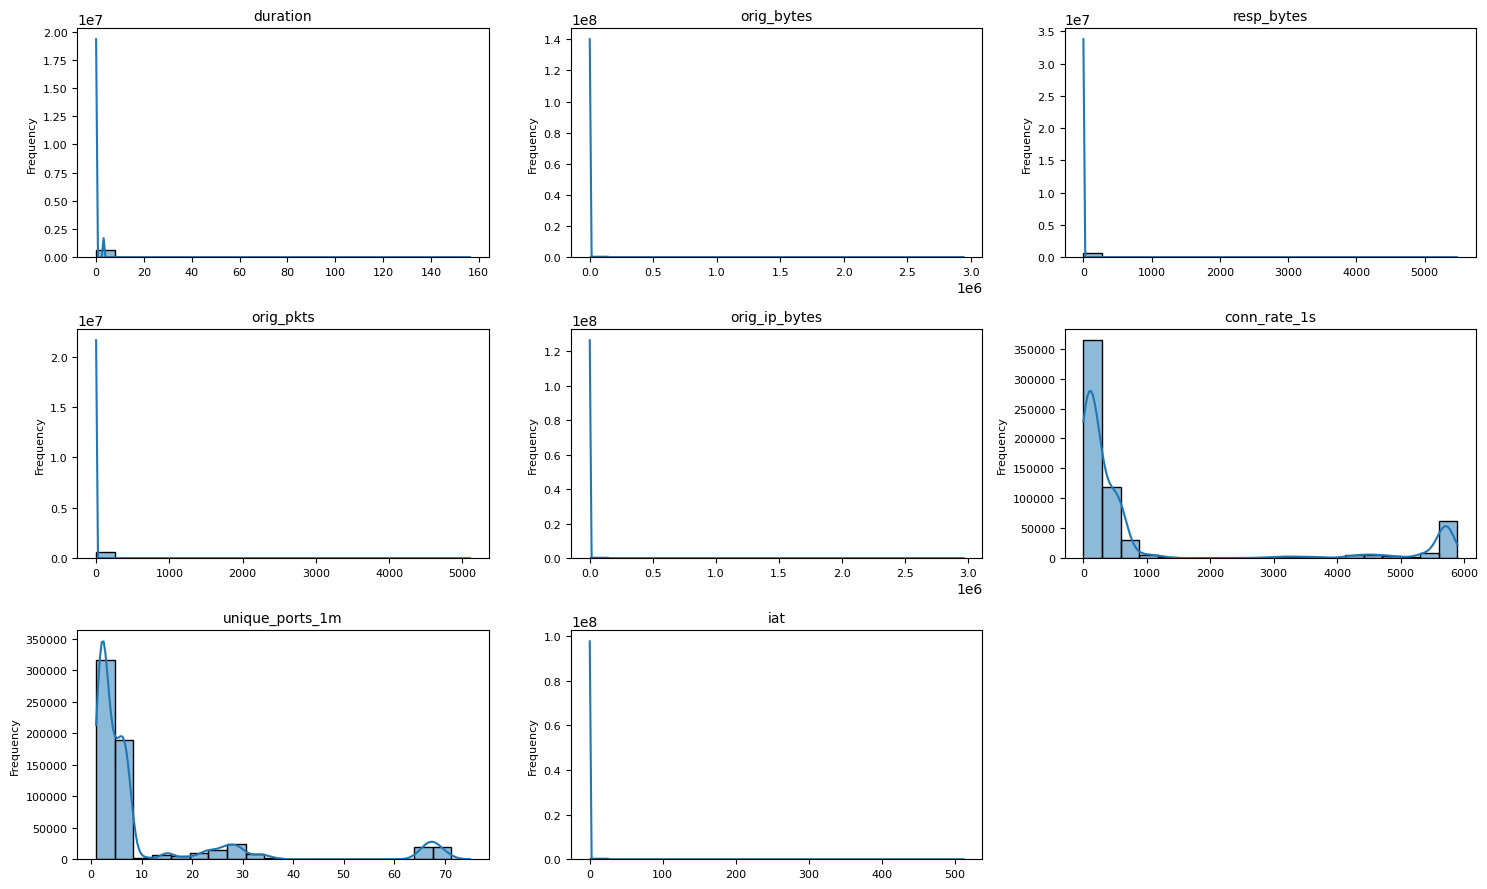



--- Generating Plots for Label: Benign ---


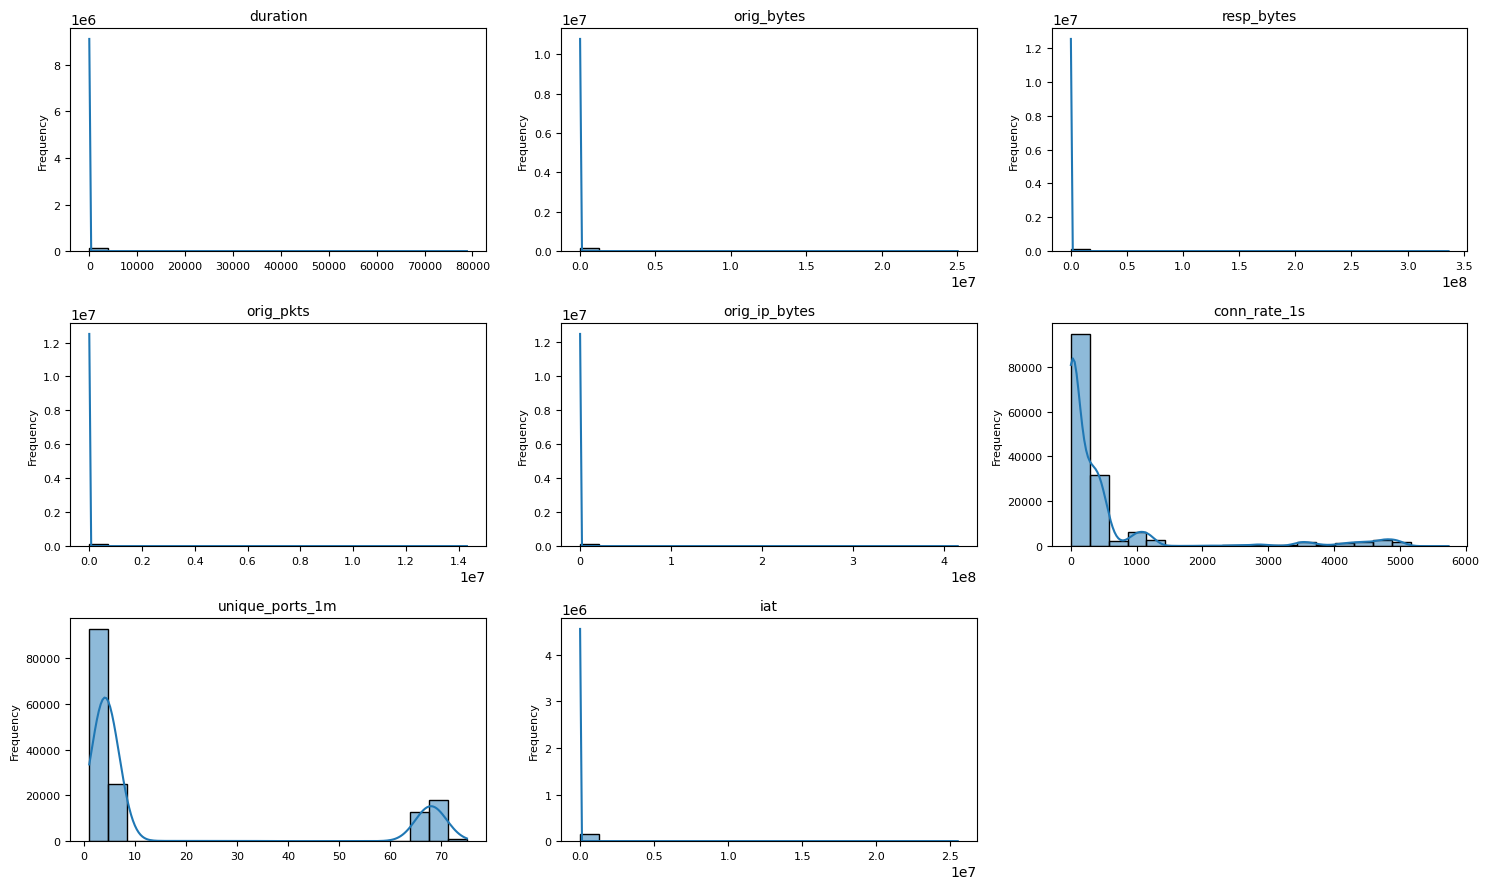



--- Generating Plots for Label: Okiru ---


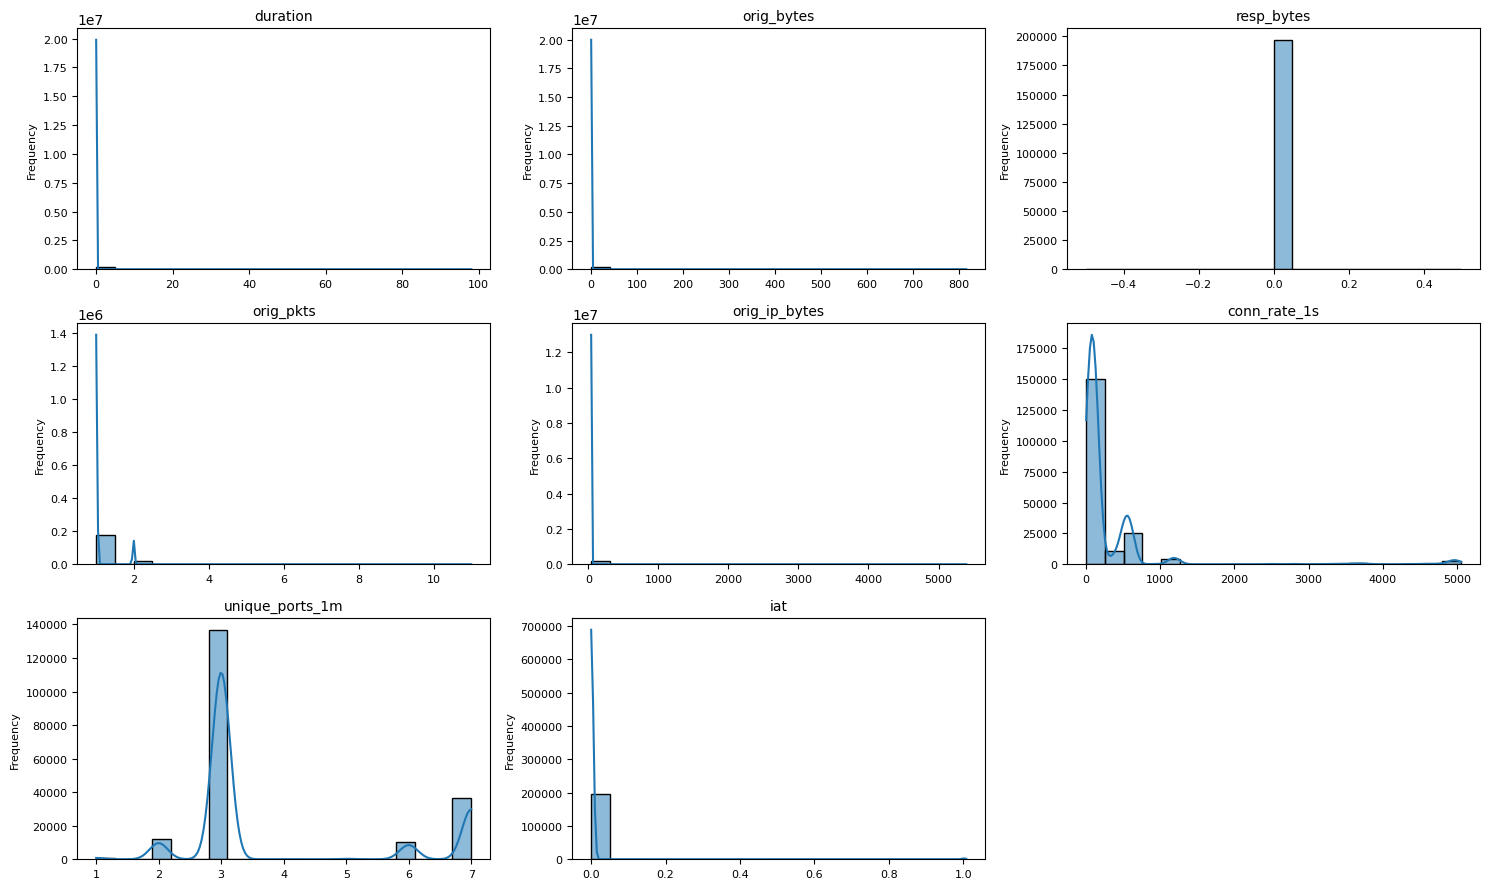



--- Generating Plots for Label: DDoS ---


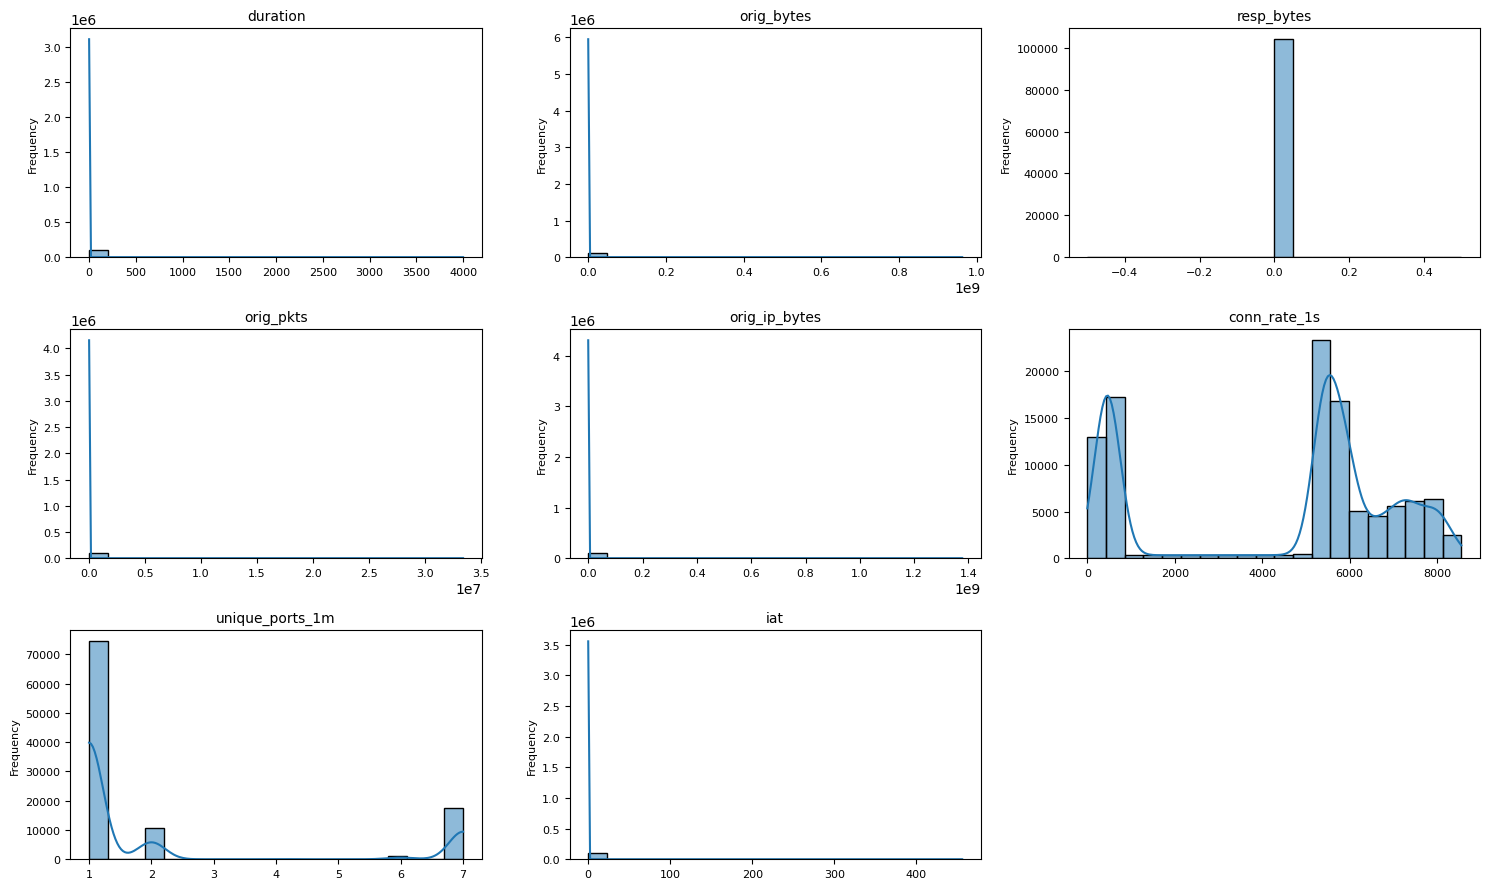



--- Generating Plots for Label: C&C ---


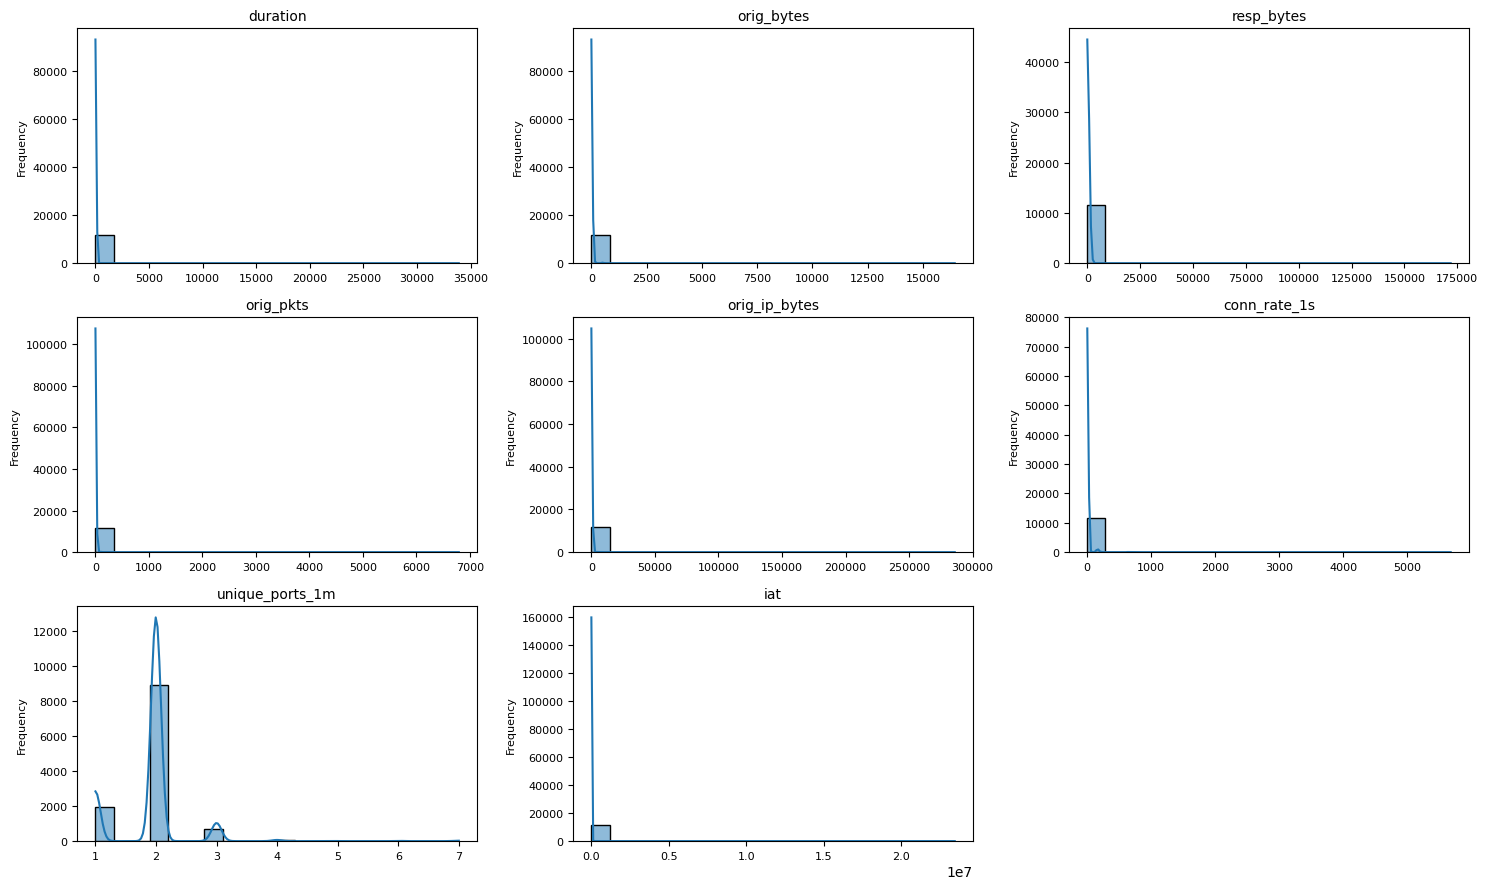



--- Generating Plots for Label: Attack ---


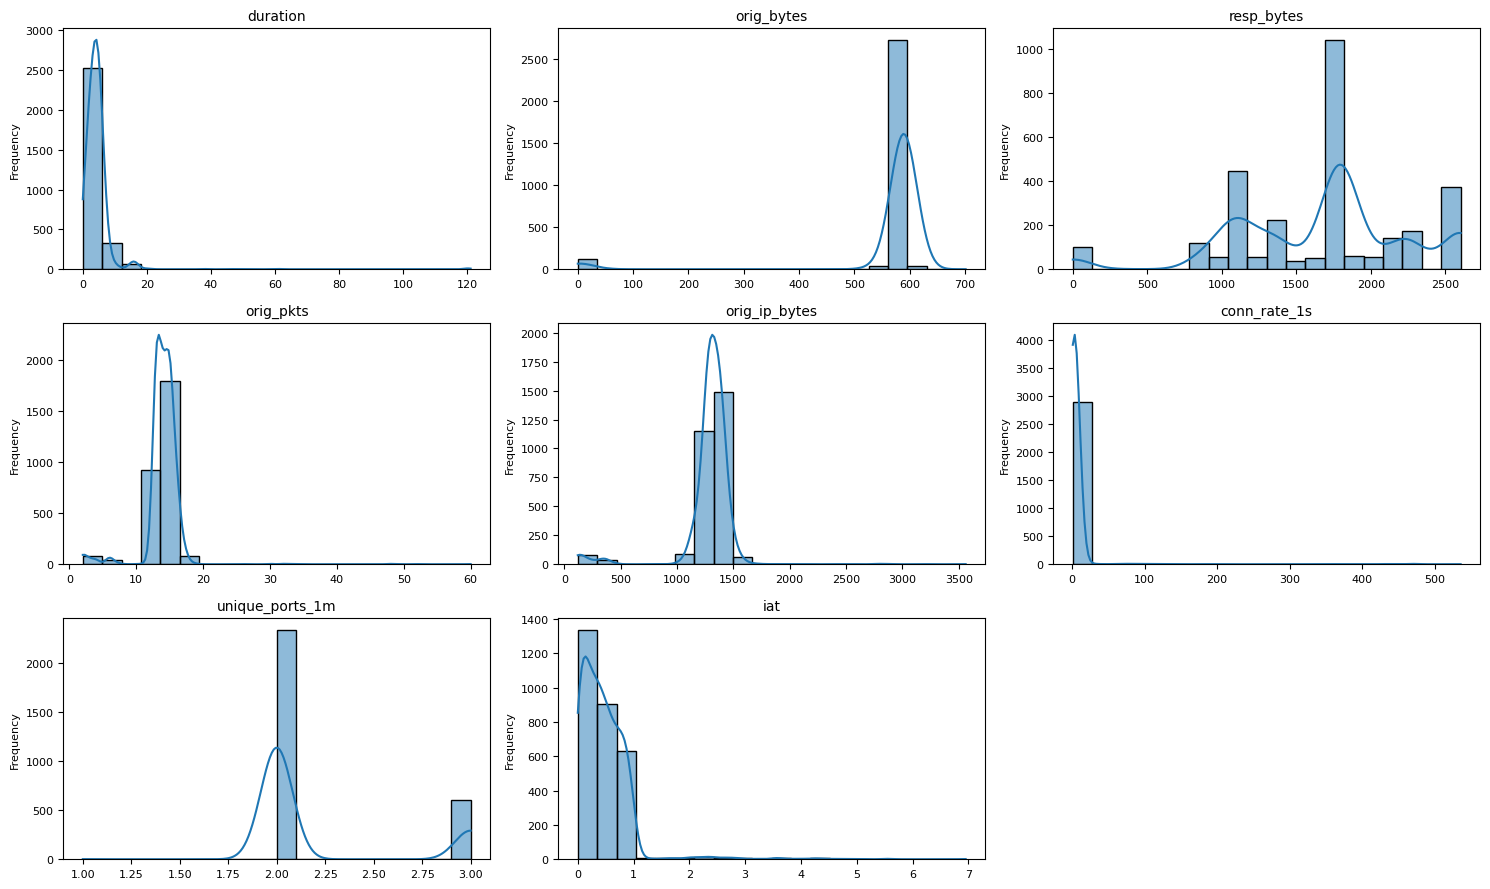

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure you have your dataframe 'df_real' loaded before this
LABEL_OPTIONS = df_real['label'].unique().tolist()
TARGET_FEATURES = ['duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'orig_ip_bytes','conn_rate_1s', 'unique_ports_1m', 'iat']

def plot_all_label_charts_colab(df, target_features, label_options):
    """Generates and displays plots for every unique label in Google Colab."""

    # Configuration for the subplots
    num_cols_per_row = 3
    num_plots = len(target_features)
    num_rows = (num_plots + num_cols_per_row - 1) // num_cols_per_row

    for selected_label in label_options:
        # Filter the DataFrame for the current label
        df_filtered = df[df['label'] == selected_label]

        if df_filtered.empty:
            print(f"No data found for label: {selected_label}")
            continue

        print(f"--- Generating Plots for Label: {selected_label} ---")

        # Create the figure object
        fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(15, 3 * num_rows))
        axes = axes.flatten()

        for i, col in enumerate(target_features):
            sns.histplot(
                df_filtered[col],
                kde=True,
                bins=20,
                ax=axes[i]
            )
            axes[i].set_title(col, fontsize=10) # Added title back for clarity in Colab
            axes[i].set_xlabel(None)
            axes[i].set_ylabel('Frequency', fontsize=8)
            axes[i].tick_params(axis='both', labelsize=8)

        # Hide any unused subplots
        for j in range(i + 1, num_rows * num_cols_per_row):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show() # This is crucial for Google Colab to display the plot
        print("\n") # Adds space between different label groups

# To run it in your cell:
plot_all_label_charts_colab(df_real, TARGET_FEATURES, LABEL_OPTIONS)